# Benchmark: Serial vs Parallel Iterative SLSQP

Compares the current serial `iterative_serial` implementation against
the parallelized `iterative_parallel` which batches non-overlapping windows
into a `ProcessPoolExecutor`.

In [ ]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import os
import time

import matplotlib.pyplot as plt
import numpy as np
from benchmark_utils import (
    get_output_dir,
    log_run_footer,
    log_run_header,
    reset_figure_counter,
    results_to_rows,
    save_results_csv,
    save_summary_json,
    show_and_save,
)

import dvfopt.laplacian
from dvfopt.core.slsqp_windowed.iterative import iterative_parallel, iterative_serial, jacobian_det2D
from dvfopt.viz import plot_deformations, plot_initial_deformation


In [ ]:
METHOD = "slsqp"
NOTEBOOK_NAME = "serial-vs-parallel"
OUTPUT_DIR = get_output_dir(METHOD, NOTEBOOK_NAME, base="../../output")
reset_figure_counter()
summary = log_run_header(METHOD, NOTEBOOK_NAME, OUTPUT_DIR)


## Helper: benchmark runner

In [2]:
def benchmark(deformation_i, label, msample=None, fsample=None, n_runs=1, **kwargs):
    """Run serial and parallel, print comparison table."""
    print(f"\n{'='*70}")
    print(f"  BENCHMARK: {label}")
    print(f"  Grid: {deformation_i.shape[-2]}x{deformation_i.shape[-1]}")
    jac_init = jacobian_det2D(np.stack([deformation_i[-2], deformation_i[-1]]))
    n_neg = int((jac_init <= 0).sum())
    print(f"  Initial neg-Jdet pixels: {n_neg}")
    print(f"{'='*70}\n")

    results = {}

    for name, func in [("Serial", iterative_serial),
                        ("Parallel", iterative_parallel)]:
        times = []
        for _run in range(n_runs):
            t0 = time.perf_counter()
            phi = func(deformation_i.copy(), verbose=0, **kwargs)
            elapsed = time.perf_counter() - t0
            times.append(elapsed)

        jac_final = jacobian_det2D(phi)
        final_neg = int((jac_final <= 0).sum())
        final_min = float(jac_final.min())
        l2_err = float(np.sqrt(np.sum((phi - np.stack([deformation_i[-2, 0], deformation_i[-1, 0]]))**2)))

        avg_t = np.mean(times)
        std_t = np.std(times) if n_runs > 1 else 0.0

        results[name] = {
            "time_avg": avg_t,
            "time_std": std_t,
            "times": times,
            "final_neg": final_neg,
            "final_min": final_min,
            "l2_err": l2_err,
            "phi": phi,
        }

        print(f"  {name:10s}:  {avg_t:8.2f}s (±{std_t:.2f}s)  |  "
              f"neg_jdet={final_neg}  min_jdet={final_min:+.6f}  L2={l2_err:.4f}")

    # Speedup
    if results["Serial"]["time_avg"] > 0:
        speedup = results["Serial"]["time_avg"] / results["Parallel"]["time_avg"]
        print(f"\n  Speedup: {speedup:.2f}x")

    print()

    # Plot corrected results for both methods
    for name in ["Serial", "Parallel"]:
        plot_deformations(
            msample, fsample, deformation_i, results[name]["phi"],
            title=f"{label} — {name}",
        )

    return results

---
## Test Case 1: 20×40 grid, 8 correspondences (from notebook)

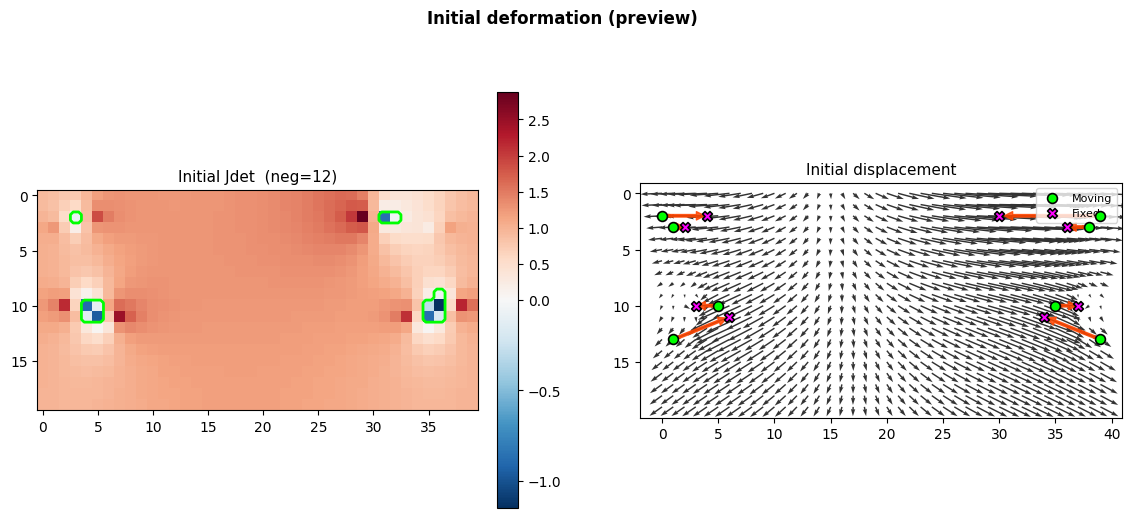


  BENCHMARK: 20x40, 8 correspondences
  Grid: 20x40
  Initial neg-Jdet pixels: 12

  Serial    :      0.13s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.2678
  Parallel  :      1.18s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=2.3052

  Speedup: 0.11x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -4.9993      8.9987      0.0000      1.9988     -1.1503      2.8771        12
 corrected     -4.9993      8.4607     -0.4086      2.0998      0.0100      2.5436         0


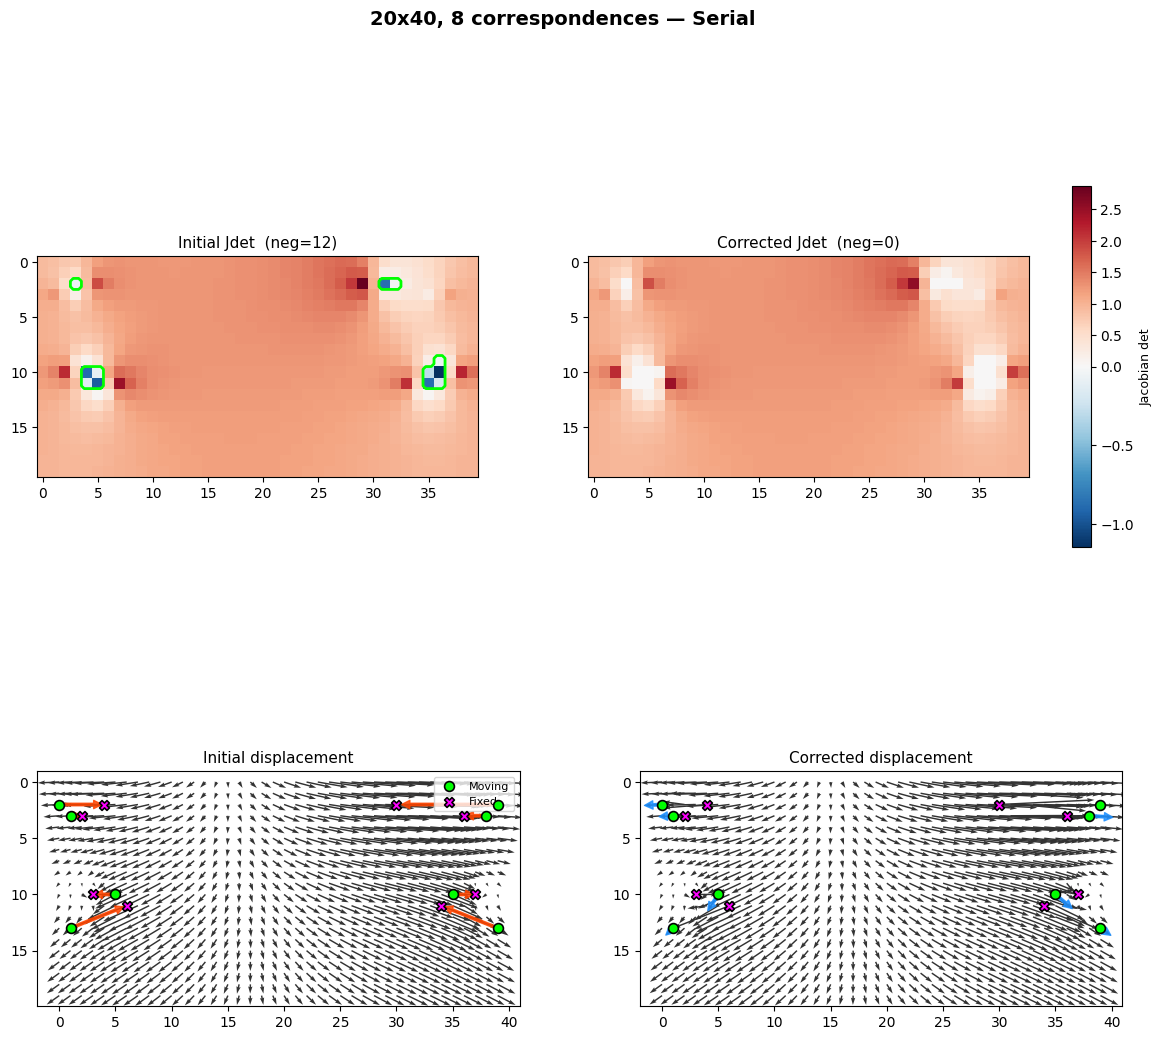

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -4.9993      8.9987      0.0000      1.9988     -1.1503      2.8771        12
 corrected     -4.9993      8.4947     -0.4542      2.1249      0.0100      2.5551         0


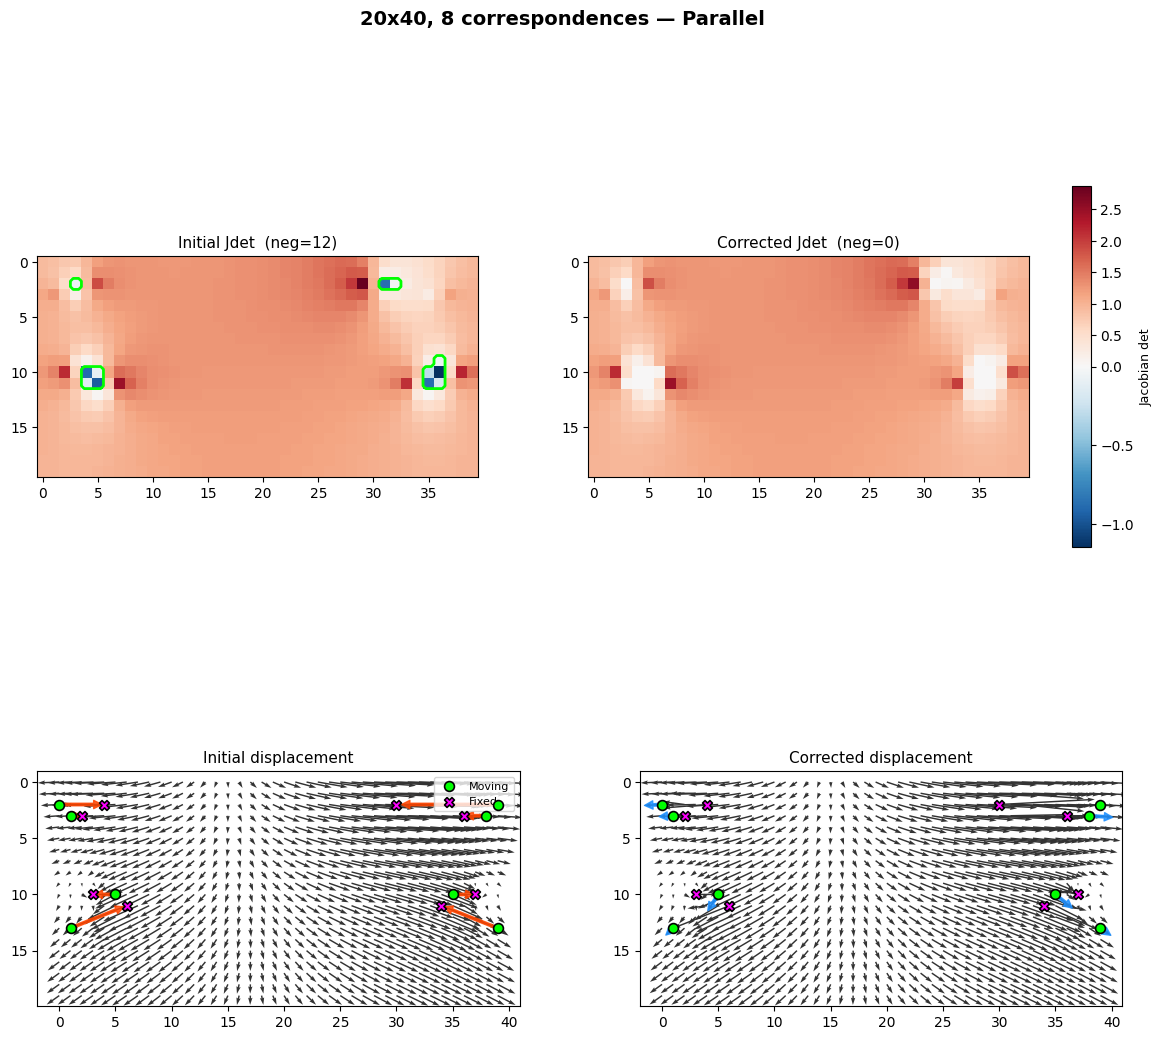

In [3]:
msample = np.array([
    [0, 2, 0],
    [0, 3, 1],
    [0, 10, 5],
    [0, 13, 1],
    [0, 2, 39],
    [0, 3, 38],
    [0, 10, 35],
    [0, 13, 39],
])
fsample = np.array([
    [0, 2, 4],
    [0, 3, 2],
    [0, 10, 3],
    [0, 11, 6],
    [0, 2, 30],
    [0, 3, 36],
    [0, 10, 37],
    [0, 11, 34]
])

fixed_sample = np.zeros((1, 20, 40))
deformation_i = dvfopt.laplacian.solveLaplacianFromCorrespondences(fixed_sample.shape, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r1 = benchmark(deformation_i, "20x40, 8 correspondences", msample, fsample)

## Test Case 2: 10×10 crossing


  BENCHMARK: 10x10, 2 crossing
  Grid: 10x10
  Initial neg-Jdet pixels: 4

  Serial    :      0.03s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1844
  Parallel  :      0.02s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1844

  Speedup: 1.31x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9997      2.9997      0.0000      0.0000     -0.6939      1.8097         4
 corrected     -2.6308      2.6436     -0.3772      0.3879      0.0100      1.6029         0


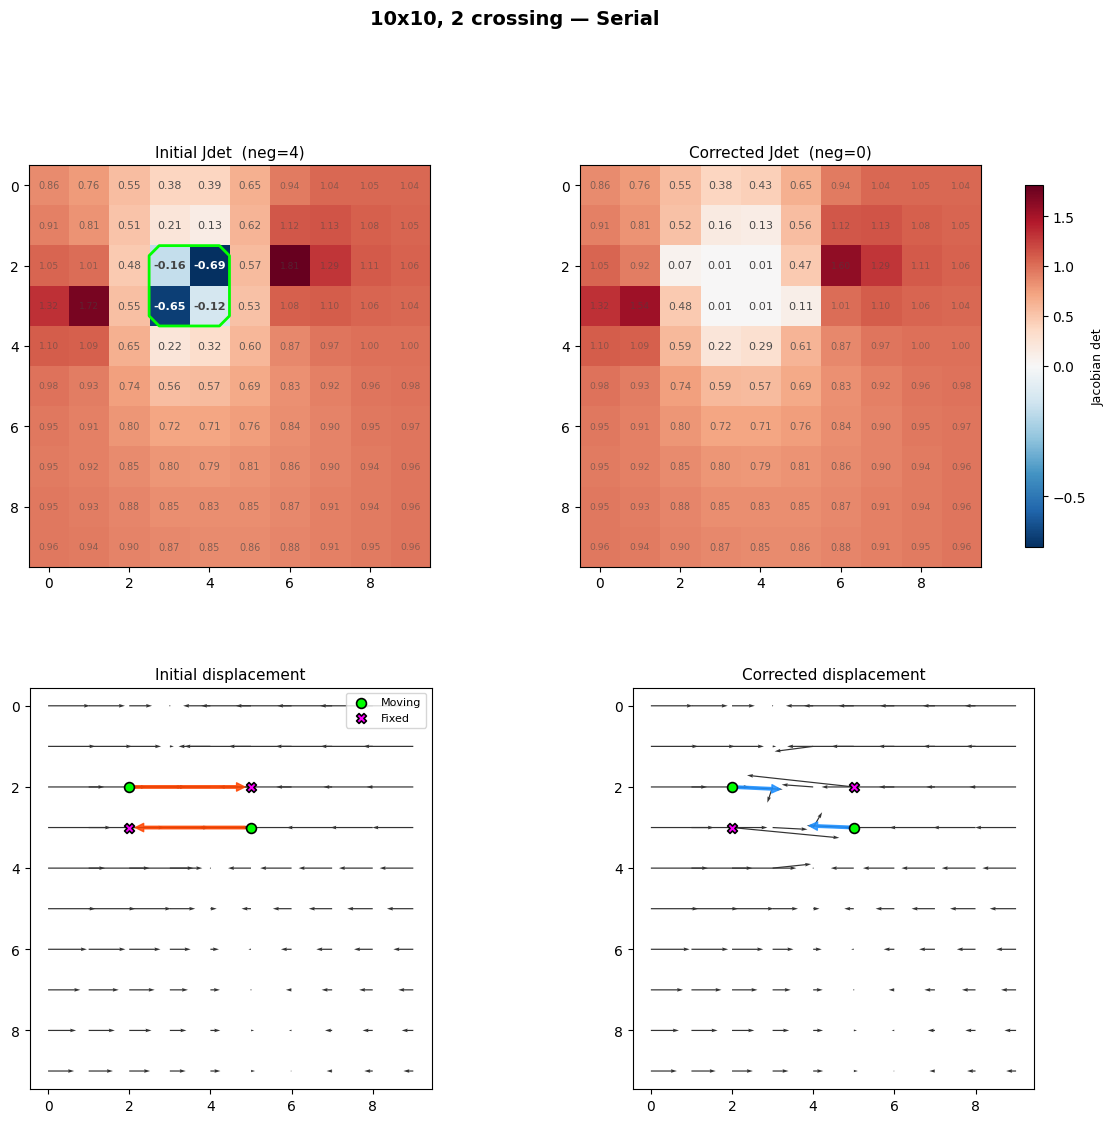

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9997      2.9997      0.0000      0.0000     -0.6939      1.8097         4
 corrected     -2.6308      2.6436     -0.3772      0.3879      0.0100      1.6029         0


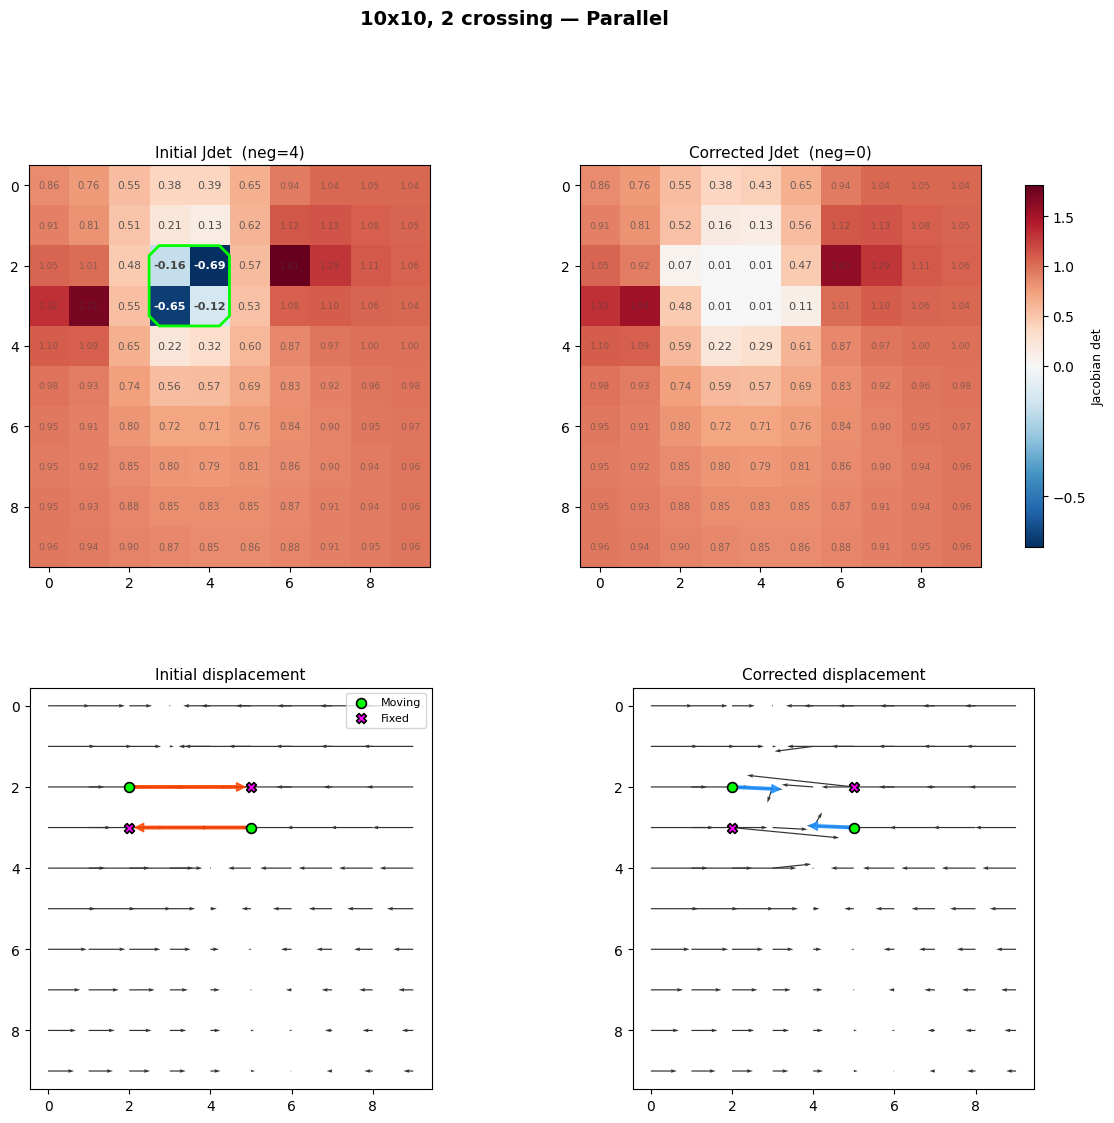

In [4]:
msample = np.array([
    [0, 2, 2],
    [0, 3, 5],
])
fsample = np.array([
    [0, 2, 5],
    [0, 3, 2],
])

fixed_sample = np.zeros((1, 10, 10))
deformation_i = dvfopt.laplacian.solveLaplacianFromCorrespondences(fixed_sample.shape, msample, fsample)

r2 = benchmark(deformation_i, "10x10, 2 crossing", msample, fsample)

## Test Case 3: 20×40, 20 correspondences (dense)

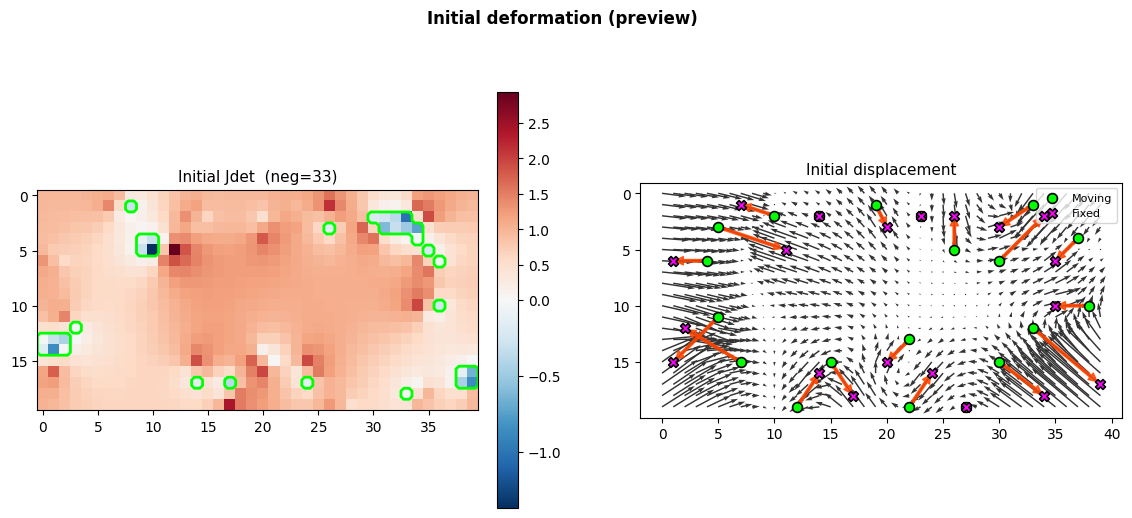


  BENCHMARK: 20x40, 20 correspondences
  Grid: 20x40
  Initial neg-Jdet pixels: 33

  Serial    :      0.72s (±0.00s)  |  neg_jdet=0  min_jdet=+0.009999  L2=3.2940
  Parallel  :     15.46s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=3.1851

  Speedup: 0.05x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -5.9994      4.9995     -4.9996      3.9997     -1.3727      2.9309        33
 corrected     -5.5886      5.0088     -4.7815      3.8496      0.0100      2.7307         0


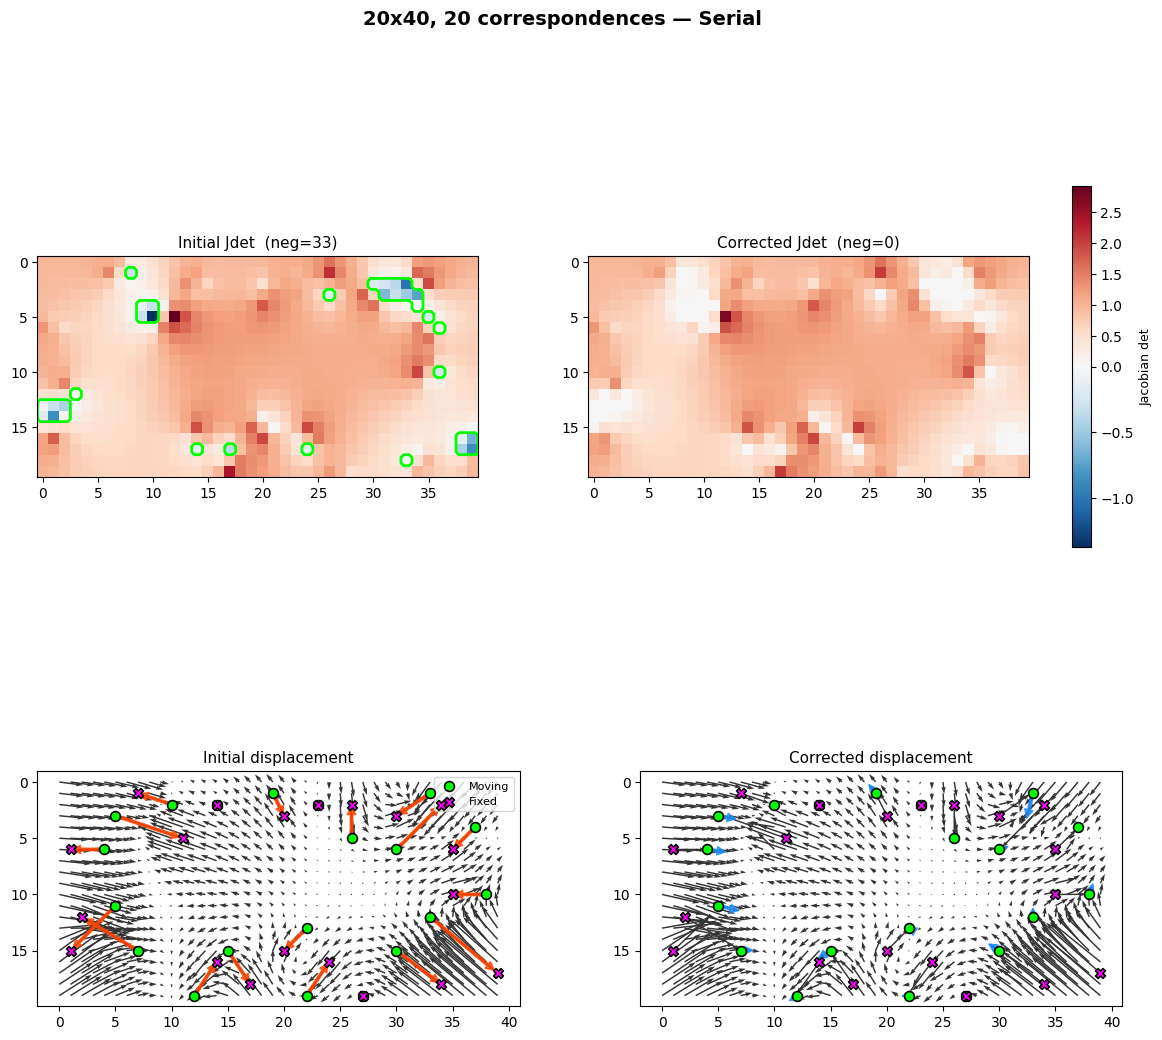

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -5.9994      4.9995     -4.9996      3.9997     -1.3727      2.9309        33
 corrected     -5.7403      5.0088     -4.7817      3.8494      0.0100      2.3497         0


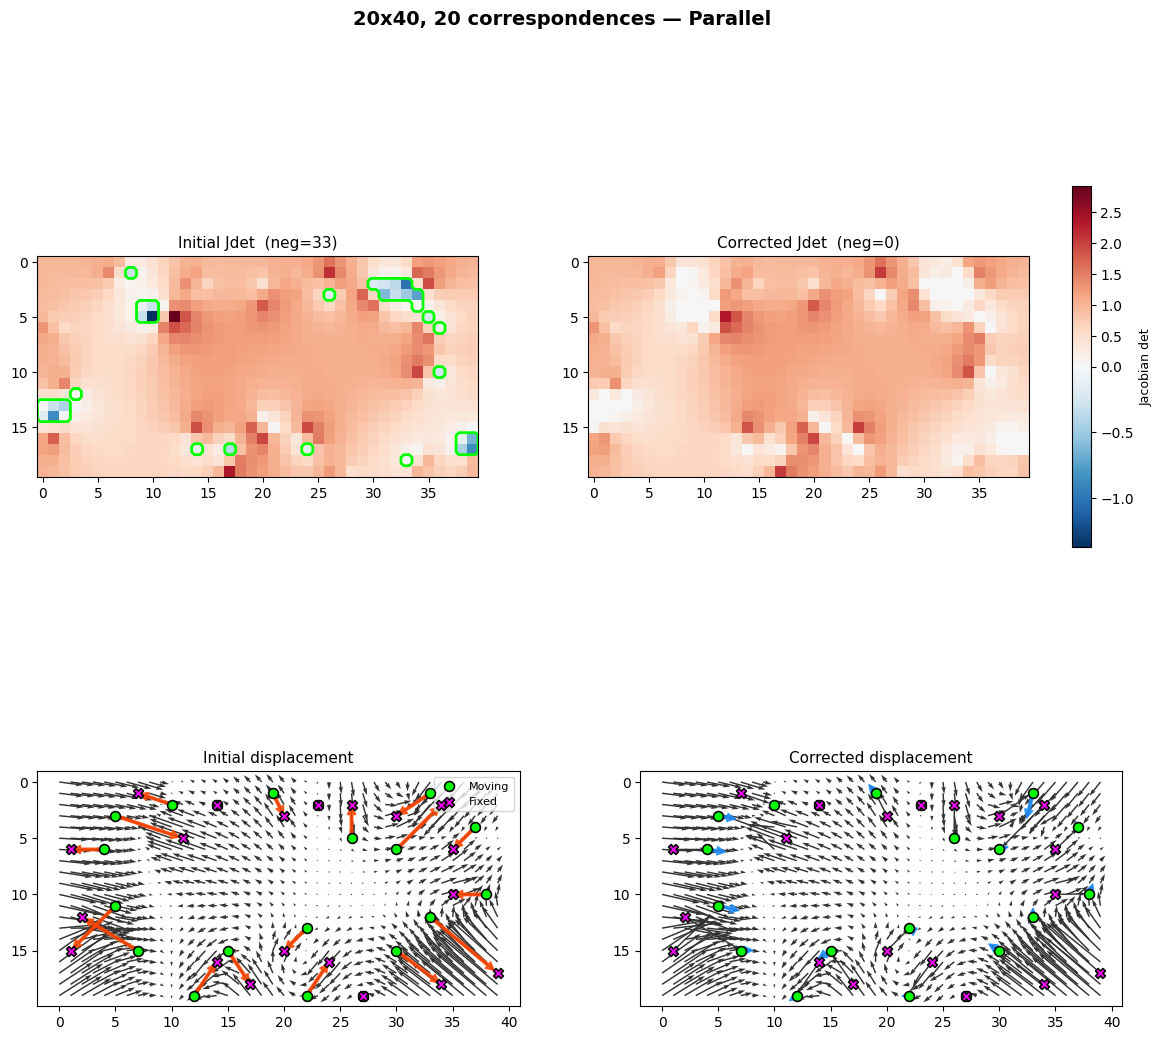

In [5]:
msample = np.array([
    [0, 2, 10],
    [0, 3, 5],
    [0, 6, 4],
    [0, 11, 5],
    [0, 15, 7],
    [0, 19, 12],
    [0, 15, 15],
    [0, 13, 22],
    [0, 19, 22],
    [0, 19, 27],
    [0, 15, 30],
    [0, 12, 33],
    [0, 10, 38],
    [0, 4, 37],
    [0, 6, 30],
    [0, 1, 33],
    [0, 5, 26],
    [0, 2, 23],
    [0, 1, 19],
    [0, 2, 14],
])
fsample = np.array([
    [0, 1, 7],
    [0, 5, 11],
    [0, 6, 1],
    [0, 15, 1],
    [0, 12, 2],
    [0, 16, 14],
    [0, 18, 17],
    [0, 15, 20],
    [0, 16, 24],
    [0, 19, 27],
    [0, 18, 34],
    [0, 17, 39],
    [0, 10, 35],
    [0, 6, 35],
    [0, 2, 34],
    [0, 3, 30],
    [0, 2, 26],
    [0, 2, 23],
    [0, 3, 20],
    [0, 2, 14],
])

fixed_sample = np.zeros((1, 20, 40))
deformation_i = dvfopt.laplacian.solveLaplacianFromCorrespondences(fixed_sample.shape, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r3 = benchmark(deformation_i, "20x40, 20 correspondences", msample, fsample)

## Test Case 3b: 320×456, 20 correspondences (large, scattered neg-Jdet spots)

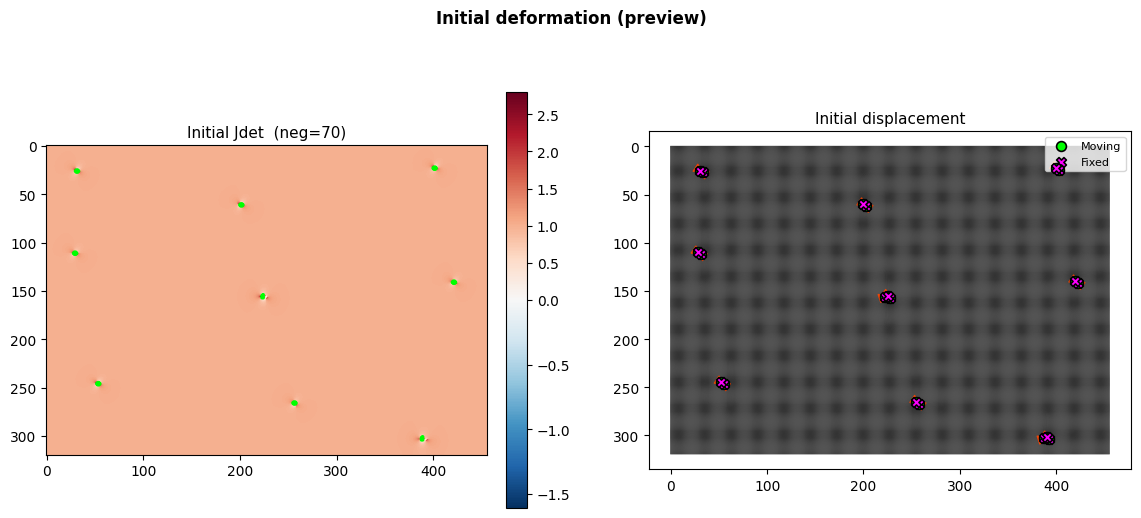


  BENCHMARK: 320x456, 20 correspondences
  Grid: 320x456
  Initial neg-Jdet pixels: 70

  Serial    :      0.91s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=5.6758
  Parallel  :      5.08s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=5.3796

  Speedup: 0.18x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9996      5.9992     -1.9999      1.9999     -1.6114      2.7962        70
 corrected     -2.9996      5.2287     -1.9999      1.7302      0.0100      2.4118         0


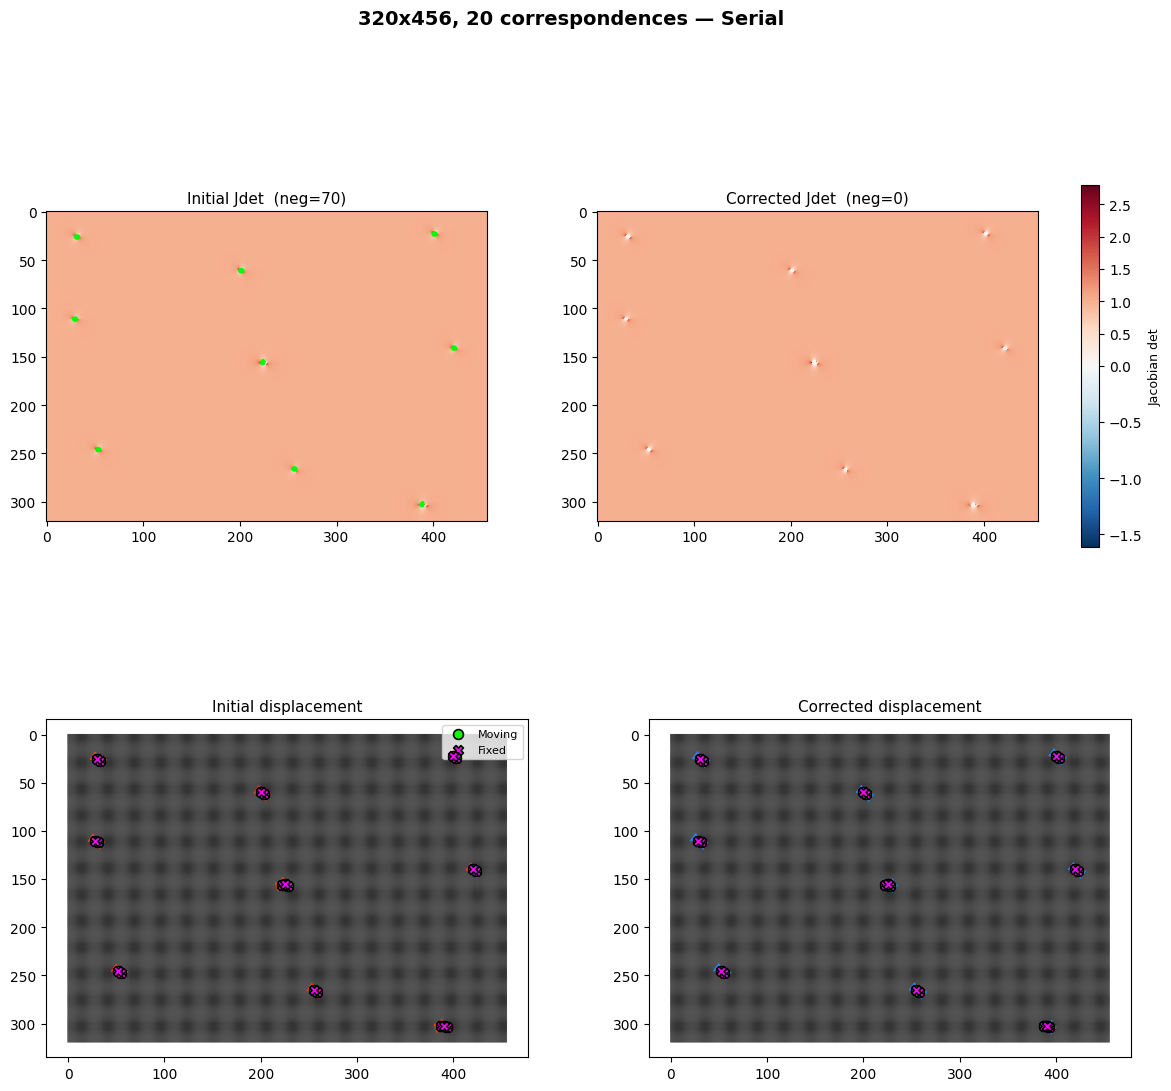

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9996      5.9992     -1.9999      1.9999     -1.6114      2.7962        70
 corrected     -2.9996      5.8460     -1.9999      1.7302      0.0100      1.7941         0


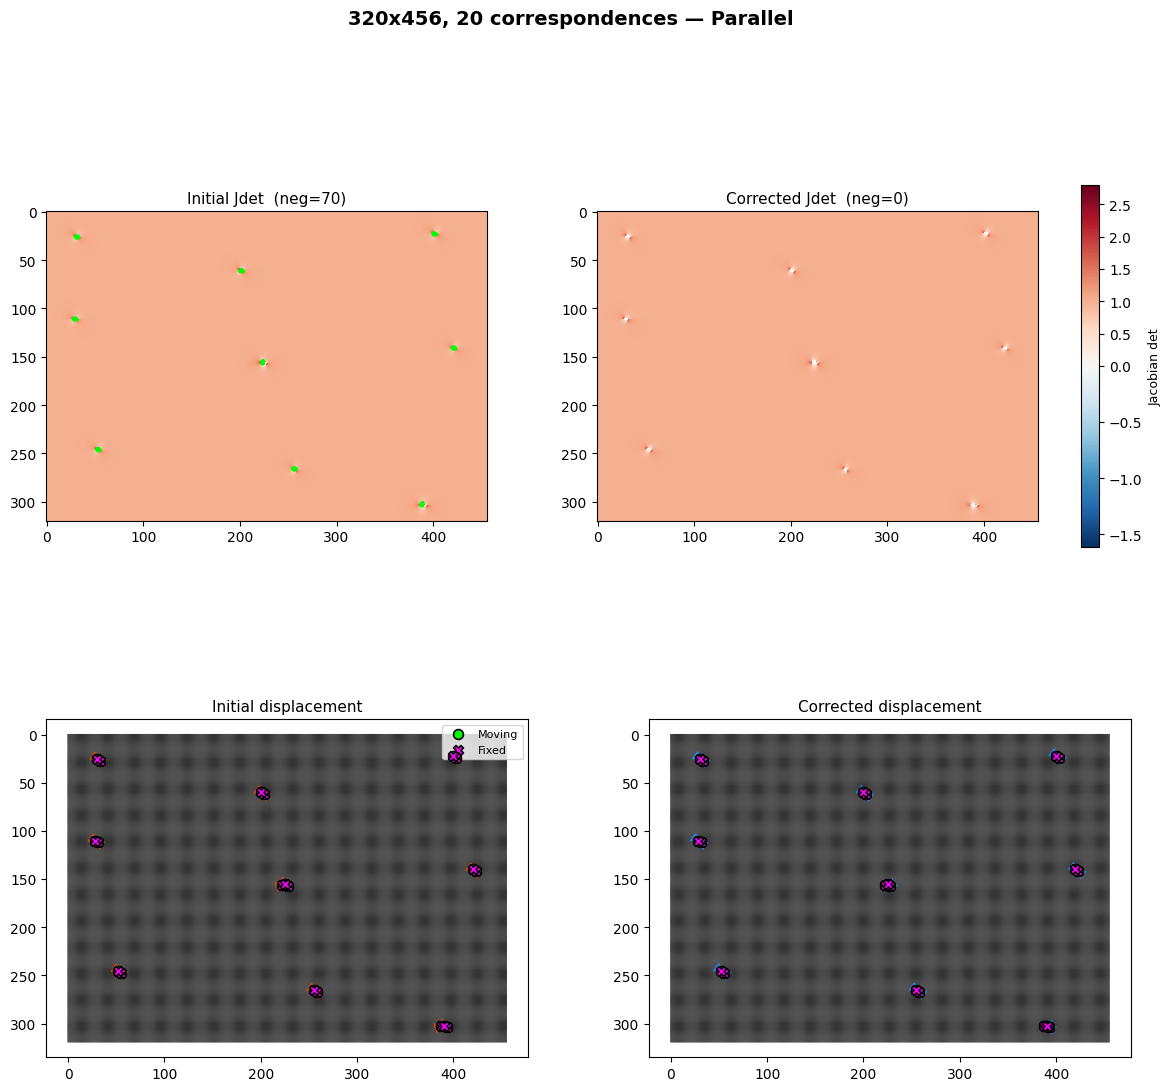

In [6]:
# 320x456 grid with ~20 correspondences scattered around the image.
# Pairs are tightly spaced (2-5 px apart) so each cluster produces a
# small, localised negative-Jdet spot rather than a broad region.

msample = np.array([
    # top-left cluster
    [0,  25,  30],
    [0,  27,  33],
    # top-right cluster
    [0,  22, 400],
    [0,  24, 403],
    # upper-middle — crossing pair
    [0,  60, 200],
    [0,  62, 203],
    # left side
    [0, 110,  28],
    [0, 112,  31],
    # centre cluster
    [0, 155, 225],
    [0, 157, 228],
    [0, 156, 222],
    # right side
    [0, 140, 420],
    [0, 142, 423],
    # lower-left
    [0, 245,  52],
    [0, 247,  55],
    # lower-centre
    [0, 265, 255],
    [0, 267, 258],
    # bottom-right cluster
    [0, 302, 390],
    [0, 304, 393],
    [0, 303, 387],
])

fsample = np.array([
    # top-left cluster — swap
    [0,  27,  33],
    [0,  25,  30],
    # top-right cluster — swap
    [0,  24, 403],
    [0,  22, 400],
    # upper-middle — swap
    [0,  62, 203],
    [0,  60, 200],
    # left side — swap
    [0, 112,  31],
    [0, 110,  28],
    # centre cluster — 3-way crossing
    [0, 157, 228],
    [0, 156, 222],
    [0, 155, 225],
    # right side — swap
    [0, 142, 423],
    [0, 140, 420],
    # lower-left — swap
    [0, 247,  55],
    [0, 245,  52],
    # lower-centre — swap
    [0, 267, 258],
    [0, 265, 255],
    # bottom-right cluster — 3-way crossing
    [0, 304, 393],
    [0, 303, 387],
    [0, 302, 390],
])

fixed_sample = np.zeros((1, 320, 456))
deformation_i = dvfopt.laplacian.solveLaplacianFromCorrespondences(fixed_sample.shape, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)

r3b = benchmark(deformation_i, "320x456, 20 correspondences", msample, fsample)

## Test Case 4: Real data — 64×91 slice

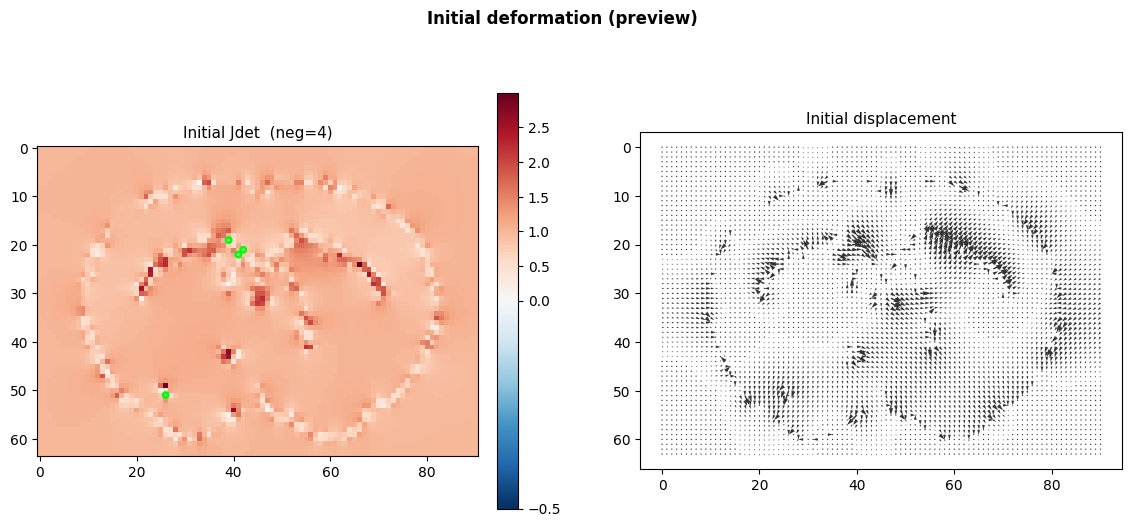


  BENCHMARK: 64x91 real slice 200
  Grid: 64x91
  Initial neg-Jdet pixels: 4

  Serial    :      0.45s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1532
  Parallel  :      2.59s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.1532

  Speedup: 0.17x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -1.9998      1.9998     -2.0002      3.0002     -0.1478      2.9999         4
 corrected     -1.9998      2.1394     -2.0002      3.2411      0.0100      3.0659         0


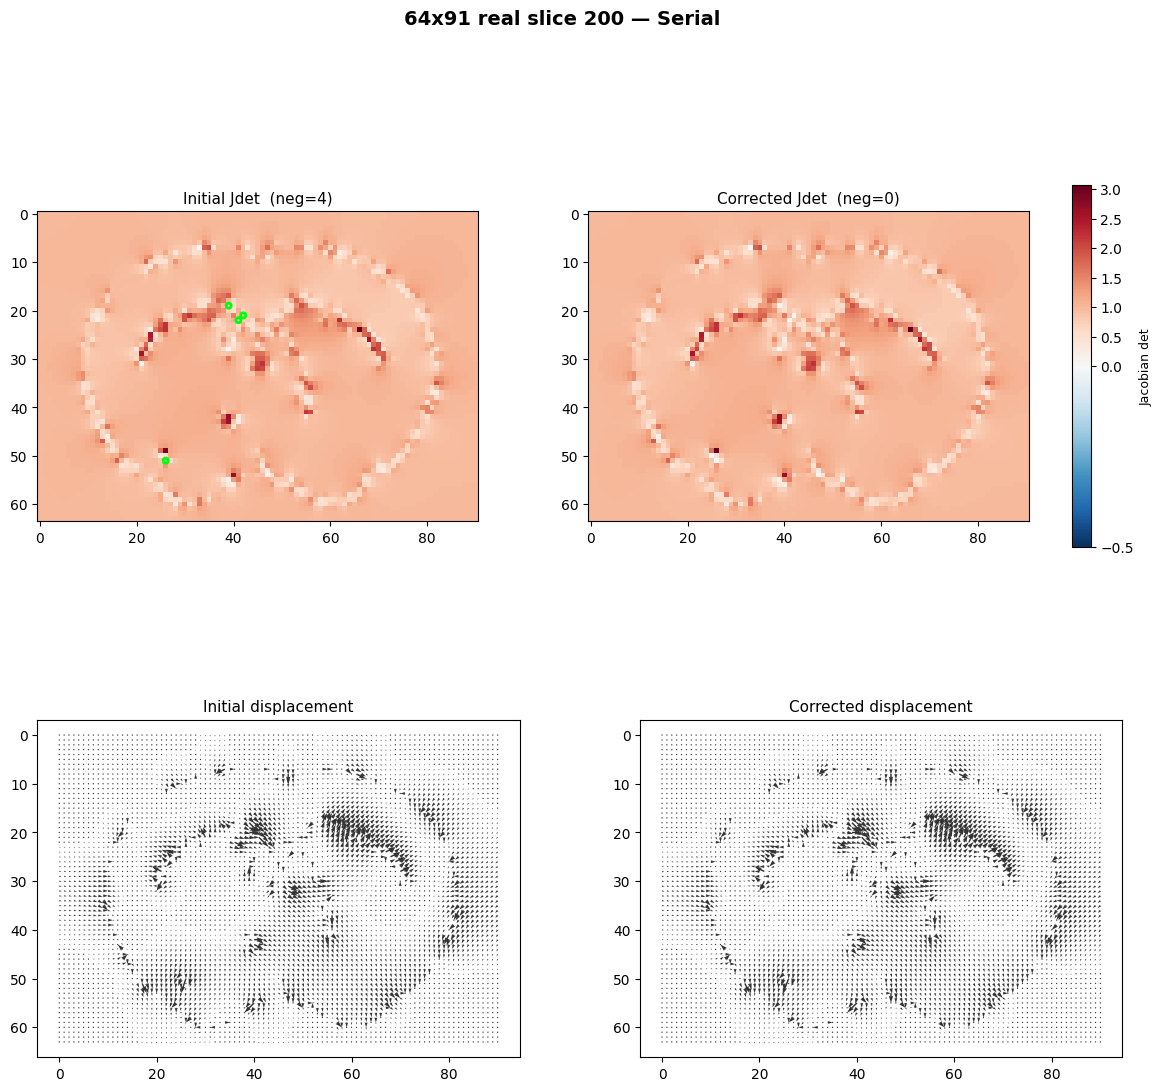

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -1.9998      1.9998     -2.0002      3.0002     -0.1478      2.9999         4
 corrected     -1.9998      2.1394     -2.0002      3.2411      0.0100      3.0659         0


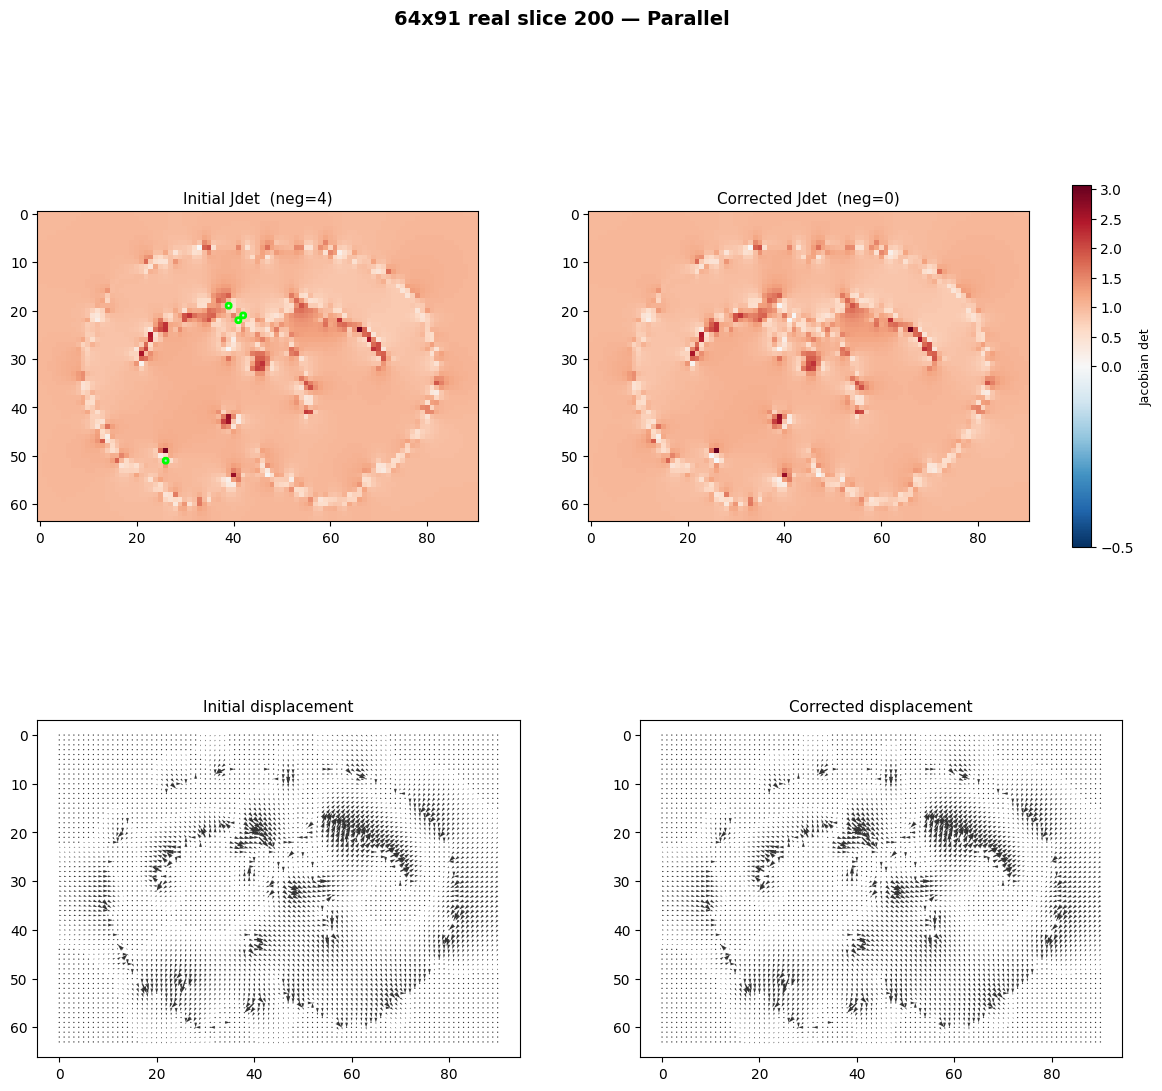

In [7]:
real_path = "../../../data/test_cases/02b_64x91_slice200.npy"
if os.path.exists(real_path):
    deformation_i = np.load(real_path)
    plot_initial_deformation(deformation_i)
    r4 = benchmark(deformation_i, "64x91 real slice 200")
else:
    print(f"Skipping — {real_path} not found")

## Test Case 5: Saved .npy test cases


  BENCHMARK: 10x10 opposites
  Grid: 10x10
  Initial neg-Jdet pixels: 14

  Serial    :      0.10s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.7927
  Parallel  :      0.08s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=1.7927

  Speedup: 1.24x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -3.9996      3.9996      0.0000      0.0000     -1.1289      2.1763        14
 corrected     -3.6892      3.9996     -0.7088      0.8081      0.0100      1.6989         0


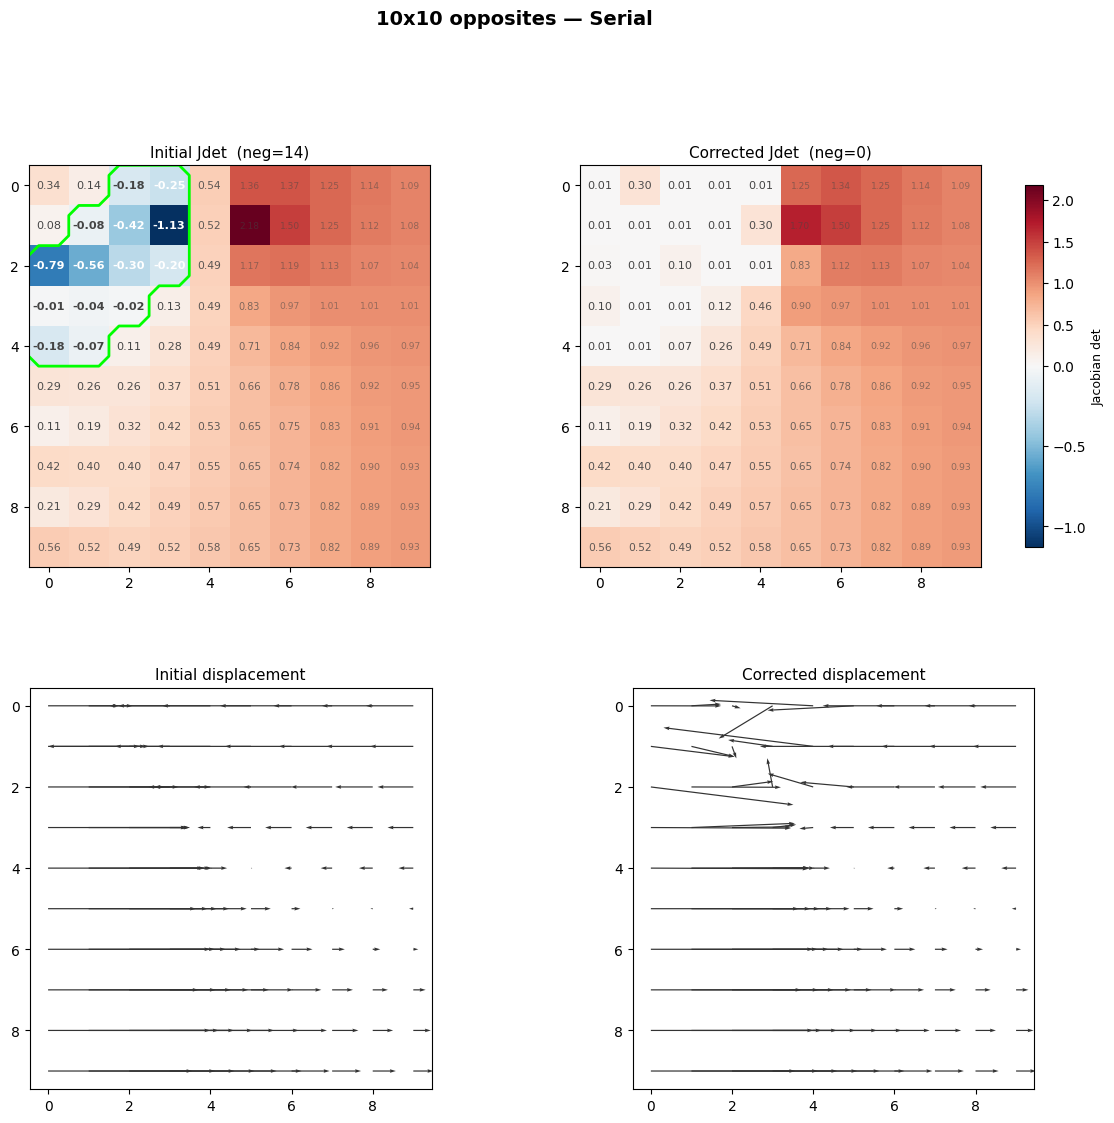

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -3.9996      3.9996      0.0000      0.0000     -1.1289      2.1763        14
 corrected     -3.6892      3.9996     -0.7088      0.8081      0.0100      1.6989         0


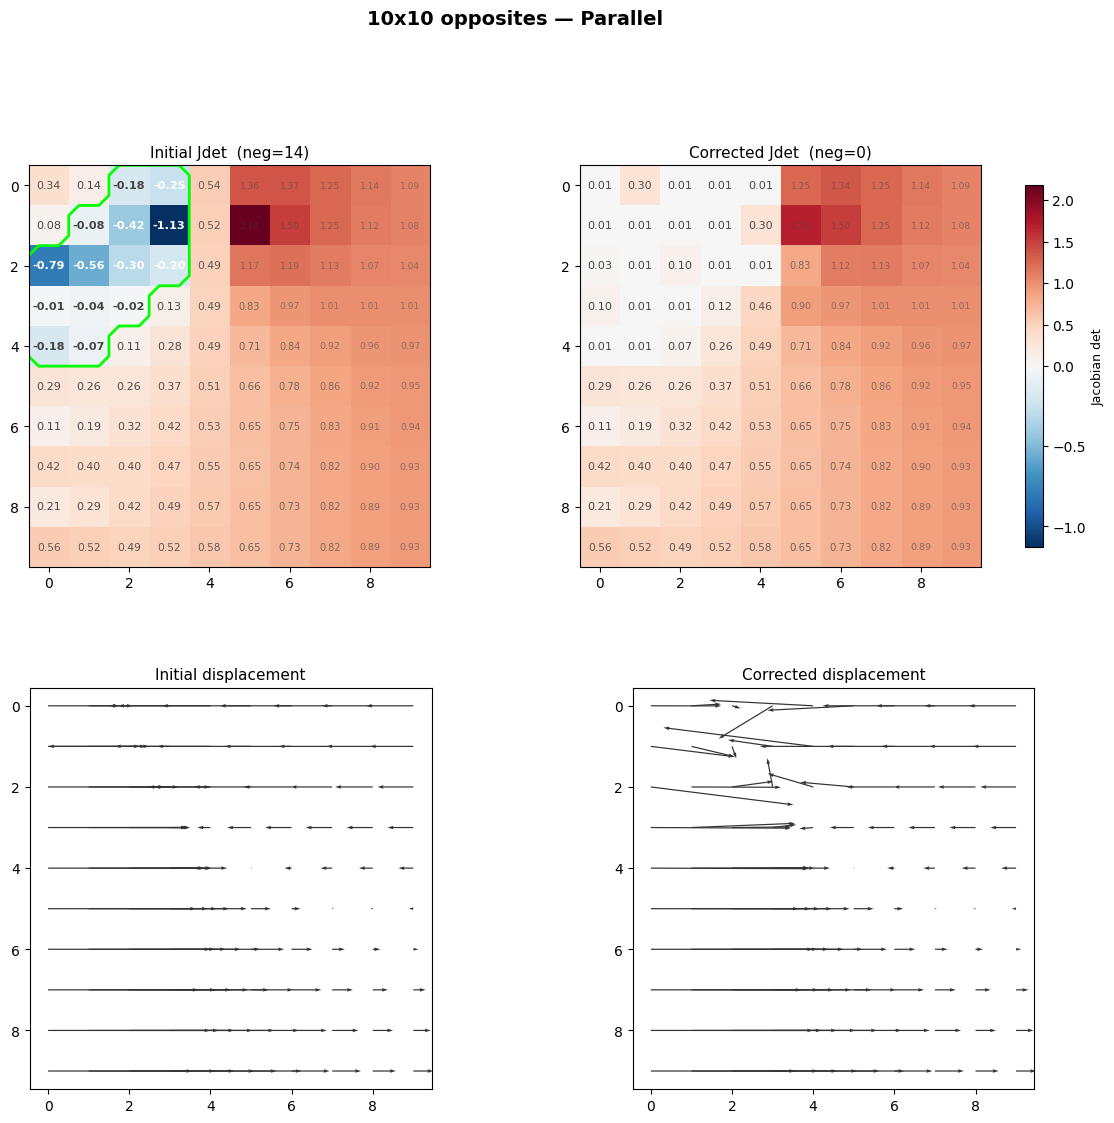


  BENCHMARK: 10x10 crossing
  Grid: 10x10
  Initial neg-Jdet pixels: 18

  Serial    :      0.16s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=4.0665
  Parallel  :      1.27s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=4.0665

  Speedup: 0.12x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9997      2.9997     -2.0214     -1.9882     -1.0478      2.8974        18
 corrected     -3.0087      3.0087     -3.0137     -0.9955      0.0100      2.9020         0


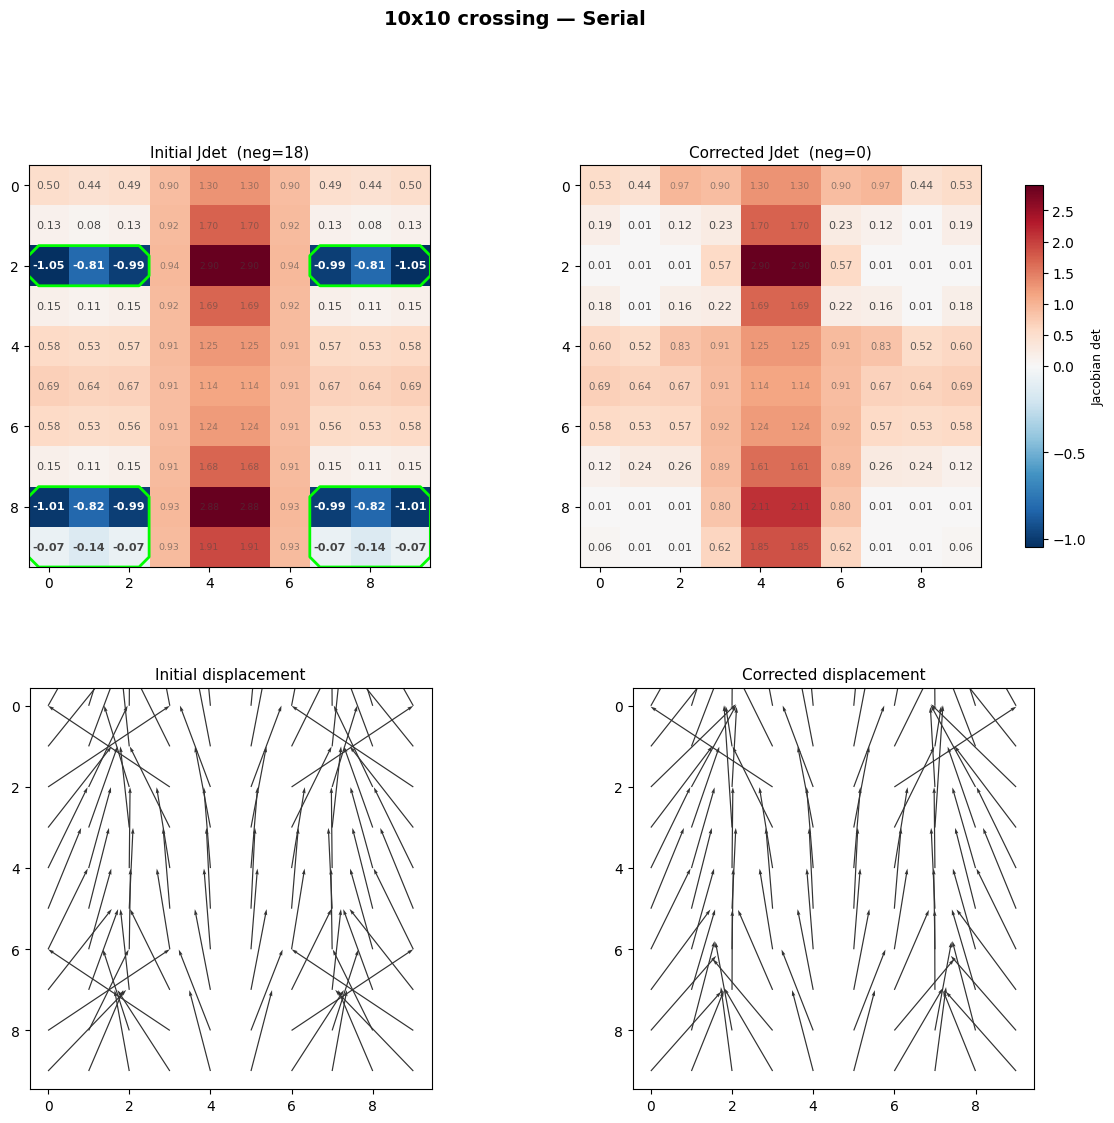

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9997      2.9997     -2.0214     -1.9882     -1.0478      2.8974        18
 corrected     -3.0084      3.0084     -3.0137     -0.9955      0.0100      2.9018         0


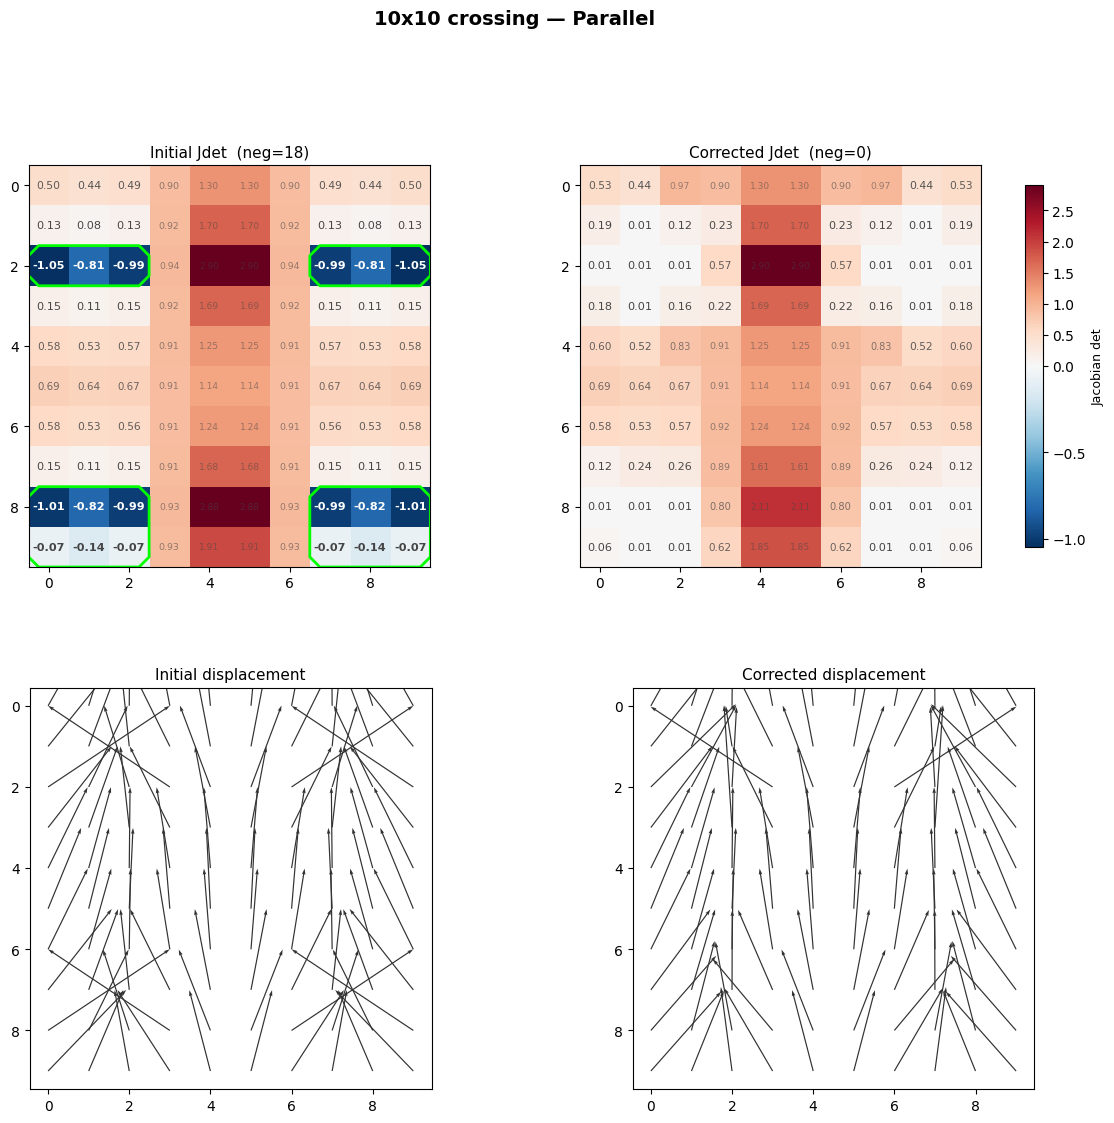


  BENCHMARK: 20x20 opposites
  Grid: 20x20
  Initial neg-Jdet pixels: 36

  Serial    :      0.23s (±0.00s)  |  neg_jdet=0  min_jdet=+0.009999  L2=4.0251
  Parallel  :      2.59s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=4.0251

  Speedup: 0.09x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -3.9996      3.9996      0.0000      0.0000     -1.4149      2.4256        36
 corrected     -3.7624      3.9796     -0.7574      0.8146      0.0100      2.0775         0


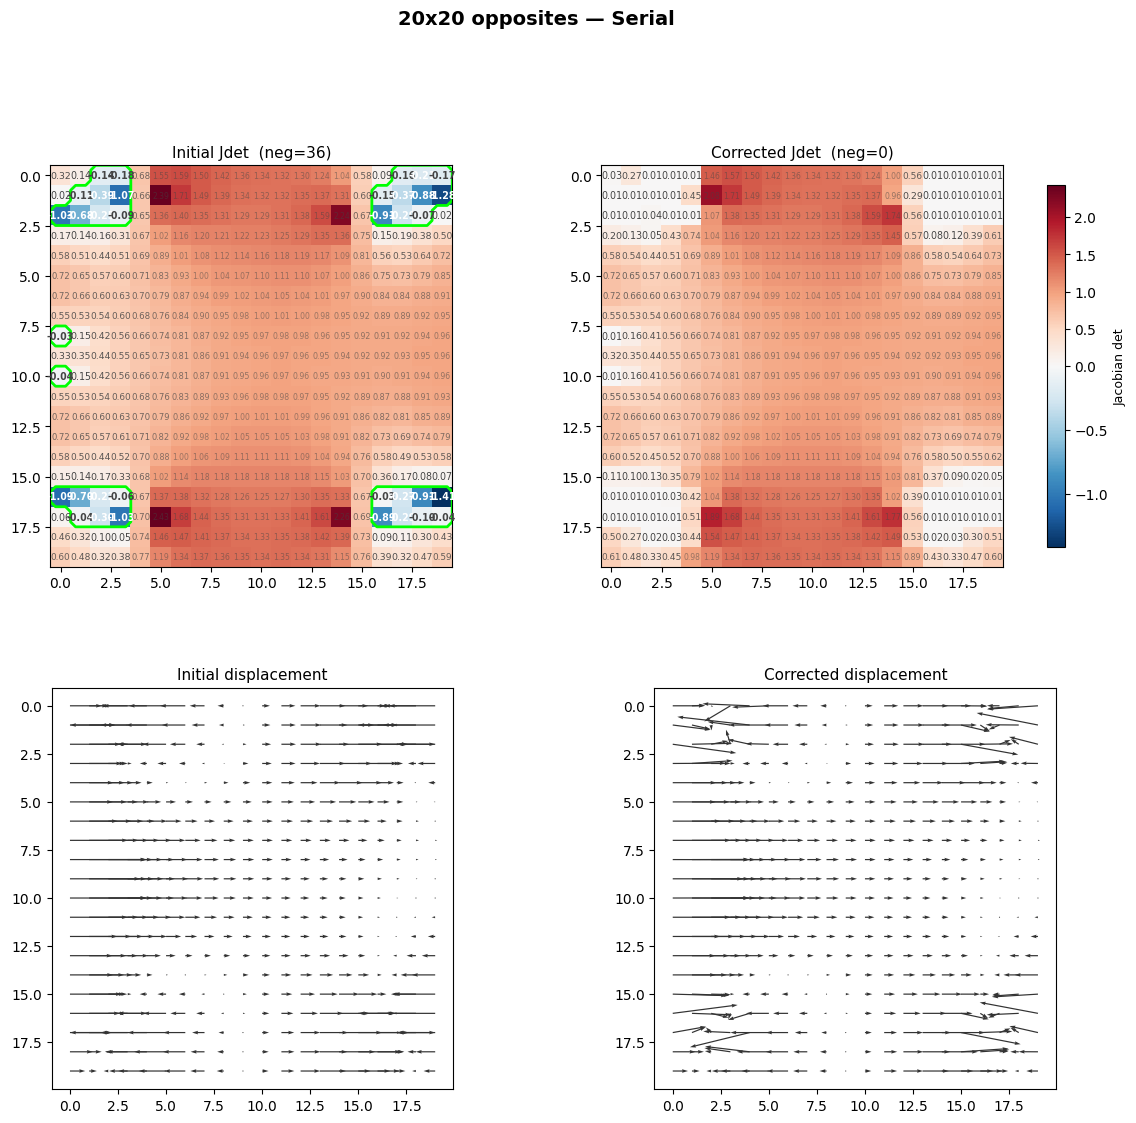

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -3.9996      3.9996      0.0000      0.0000     -1.4149      2.4256        36
 corrected     -3.7624      3.9796     -0.7574      0.8146      0.0100      2.0775         0


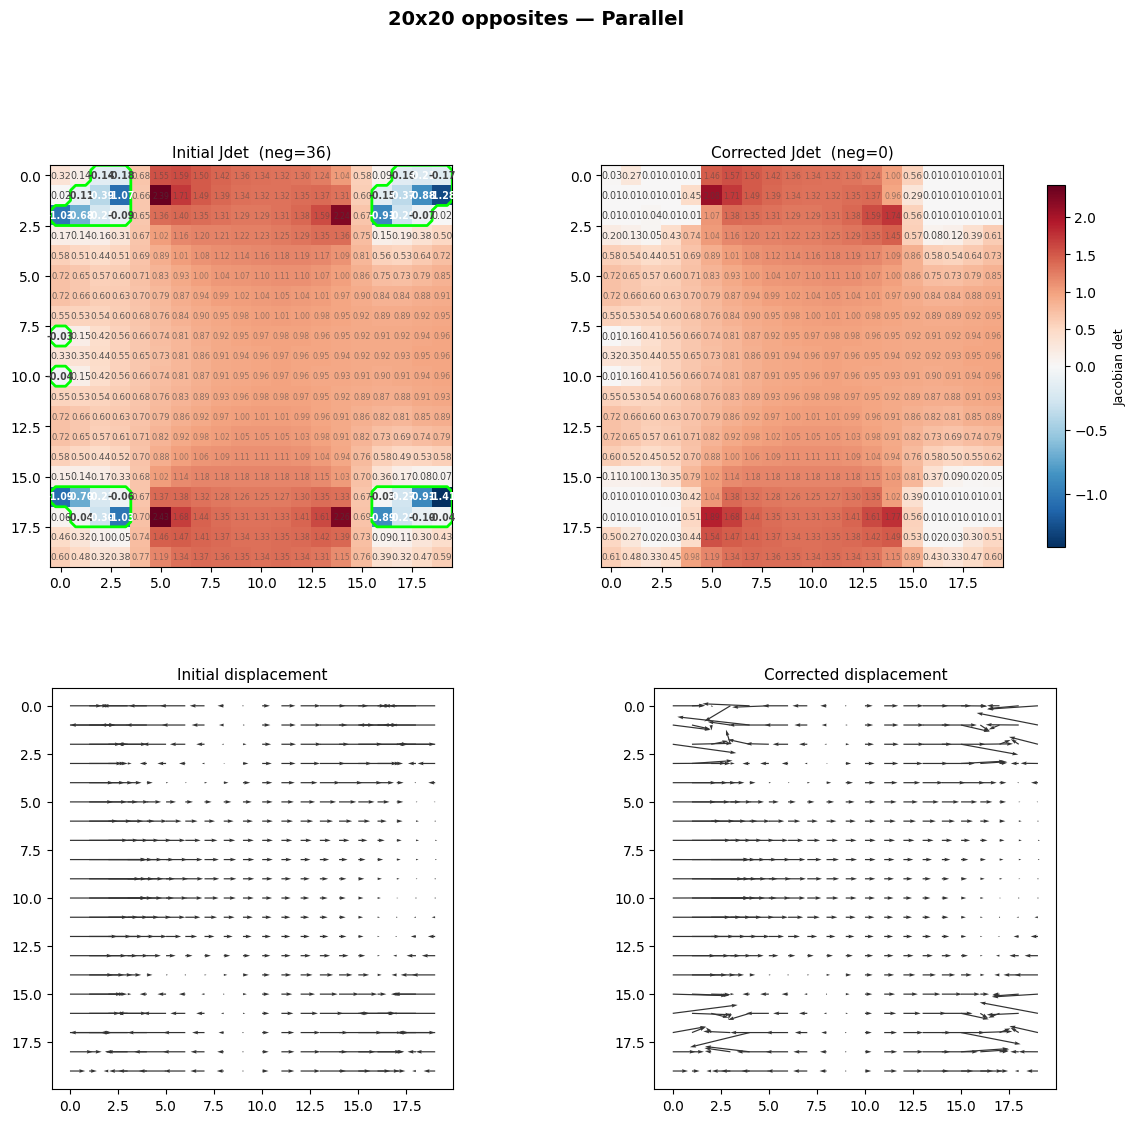


  BENCHMARK: 20x20 crossing
  Grid: 20x20
  Initial neg-Jdet pixels: 30

  Serial    :      0.35s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=7.5266
  Parallel  :      3.67s (±0.00s)  |  neg_jdet=0  min_jdet=+0.010000  L2=7.5274

  Speedup: 0.09x

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9998      2.9998     -2.9998     -1.9750     -1.0155      3.9628        30
 corrected     -3.0085      3.0078     -3.8940     -0.9849      0.0100      3.9668         0


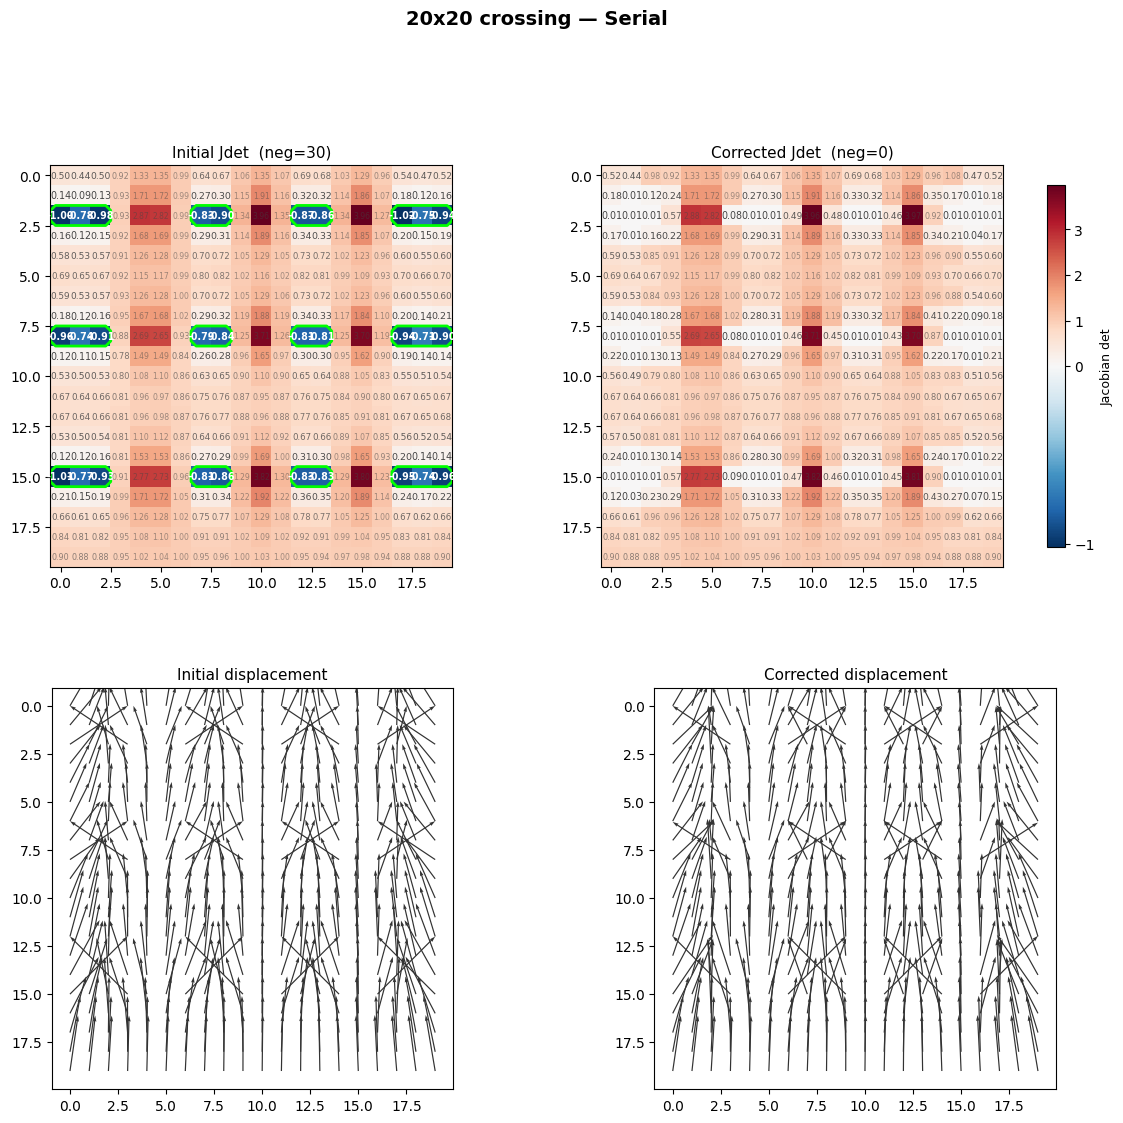

            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9998      2.9998     -2.9998     -1.9750     -1.0155      3.9628        30
 corrected     -3.0086      3.0079     -3.8710     -0.9849      0.0100      3.9668         0


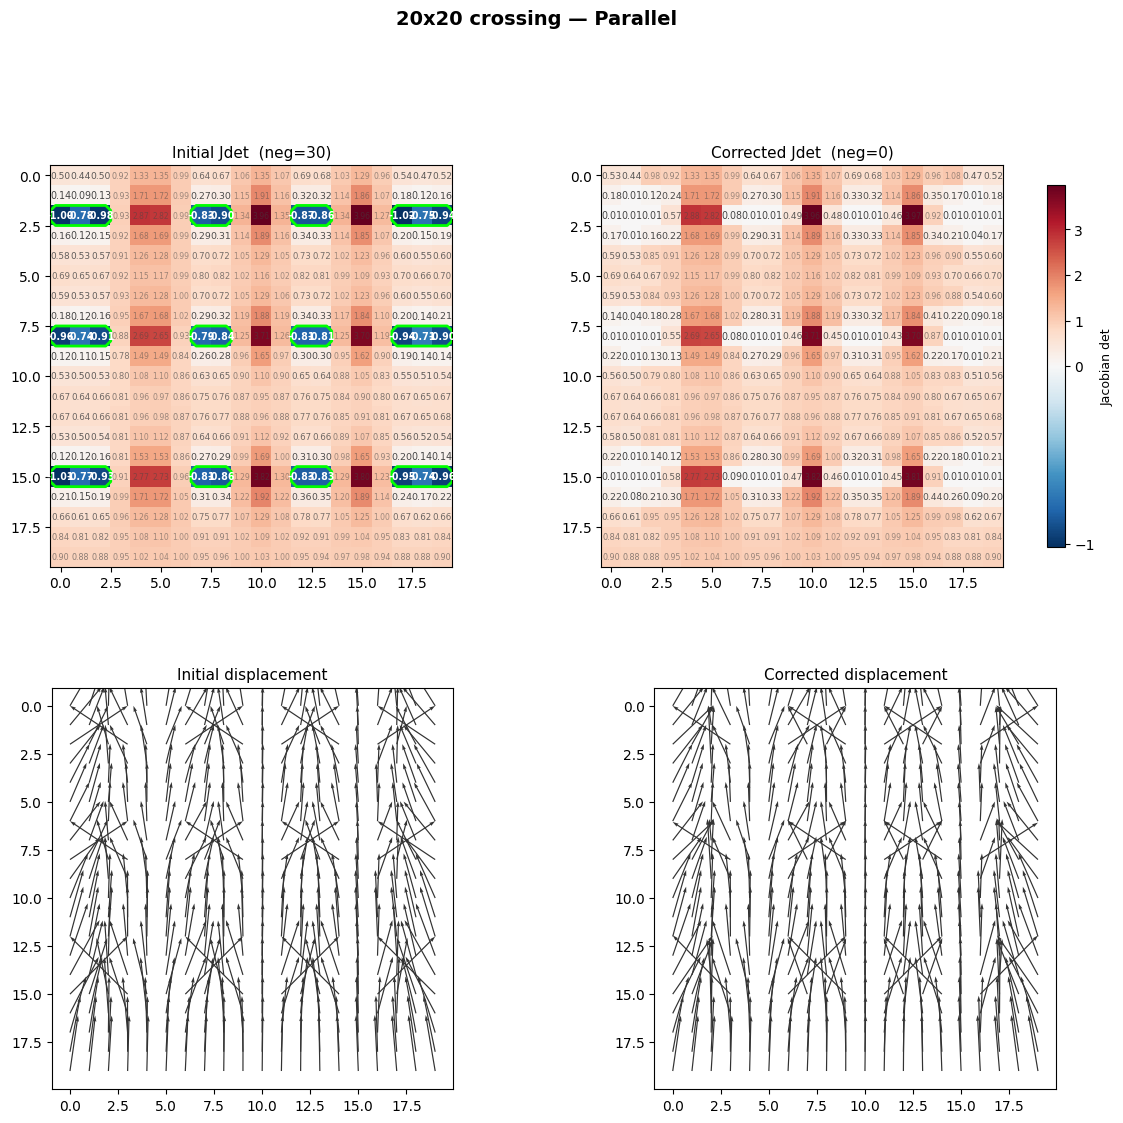

In [8]:
npy_cases = [
    ("../../../data/test_cases/03a_10x10_opposite.npy", "10x10 opposites"),
    ("../../../data/test_cases/03b_10x10_crossing.npy", "10x10 crossing"),
    ("../../../data/test_cases/03c_20x20_opposite.npy", "20x20 opposites"),
    ("../../../data/test_cases/03d_20x20_crossing.npy", "20x20 crossing"),
]

npy_results = {}
for path, label in npy_cases:
    if os.path.exists(path):
        deformation_i = np.load(path)
        npy_results[label] = benchmark(deformation_i, label)
    else:
        print(f"Skipping — {path} not found")

---
## Summary table

In [9]:
all_results = {}
for name, r in [("20x40 (8 corr)", r1),
                ("10x10 crossing", r2),
                ("20x40 (20 corr)", r3),
                ("320x456 (20 corr)", r3b)]:
    all_results[name] = r

if 'r4' in dir():
    all_results["64x91 real"] = r4

for name, r in npy_results.items():
    all_results[name] = r

print(f"{'Test Case':<22s}  {'Serial (s)':>12s}  {'Parallel (s)':>14s}  {'Speedup':>8s}  {'S neg':>6s}  {'P neg':>6s}  {'S L2':>10s}  {'P L2':>10s}")
print("-" * 110)
for label, r in all_results.items():
    s = r["Serial"]
    p = r["Parallel"]
    speedup = s["time_avg"] / p["time_avg"] if p["time_avg"] > 0 else float('inf')
    print(f"{label:<22s}  {s['time_avg']:12.2f}  {p['time_avg']:14.2f}  {speedup:7.2f}x  "
          f"{s['final_neg']:6d}  {p['final_neg']:6d}  {s['l2_err']:10.4f}  {p['l2_err']:10.4f}")

# Summary stats
print()
print("=" * 110)
speedups = {}
for label, r in all_results.items():
    s_t = r["Serial"]["time_avg"]
    p_t = r["Parallel"]["time_avg"]
    speedups[label] = s_t / p_t if p_t > 0 else float('inf')

best_label = max(speedups, key=speedups.get)
worst_label = min(speedups, key=speedups.get)

total_serial = sum(r["Serial"]["time_avg"] for r in all_results.values())
total_parallel = sum(r["Parallel"]["time_avg"] for r in all_results.values())
overall_speedup = total_serial / total_parallel if total_parallel > 0 else float('inf')

# Check correctness: all parallel runs should have 0 remaining neg-Jdet
all_correct = all(r["Parallel"]["final_neg"] == 0 for r in all_results.values())

print(f"  Best speedup  : {speedups[best_label]:.2f}x  ({best_label})")
print(f"  Worst speedup : {speedups[worst_label]:.2f}x  ({worst_label})")
print(f"  Overall       : {overall_speedup:.2f}x  (total {total_serial:.1f}s serial → {total_parallel:.1f}s parallel)")
print(f"  Correctness   : {'All parallel runs reached 0 neg-Jdet' if all_correct else 'WARNING: some parallel runs have remaining neg-Jdet!'}")
print("=" * 110)

Test Case                 Serial (s)    Parallel (s)   Speedup   S neg   P neg        S L2        P L2
--------------------------------------------------------------------------------------------------------------
20x40 (8 corr)                  0.13            1.18     0.11x       0       0      2.2678      2.3052
10x10 crossing                  0.16            1.27     0.12x       0       0      4.0665      4.0665
20x40 (20 corr)                 0.72           15.46     0.05x       0       0      3.2940      3.1851
320x456 (20 corr)               0.91            5.08     0.18x       0       0      5.6758      5.3796
64x91 real                      0.45            2.59     0.17x       0       0      1.1532      1.1532
10x10 opposites                 0.10            0.08     1.24x       0       0      1.7927      1.7927
20x20 opposites                 0.23            2.59     0.09x       0       0      4.0251      4.0251
20x20 crossing                  0.35            3.67     0.09x   

## Summary plots

In [ ]:
labels = list(all_results.keys())
s_times = [all_results[l]["Serial"]["time_avg"] for l in labels]
p_times = [all_results[l]["Parallel"]["time_avg"] for l in labels]
speedup_vals = [s / p if p > 0 else 0 for s, p in zip(s_times, p_times)]
s_l2 = [all_results[l]["Serial"]["l2_err"] for l in labels]
p_l2 = [all_results[l]["Parallel"]["l2_err"] for l in labels]
s_min = [all_results[l]["Serial"]["final_min"] for l in labels]
p_min = [all_results[l]["Parallel"]["final_min"] for l in labels]

x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Grouped bar: runtime
ax = axes[0, 0]
ax.bar(x - w/2, s_times, w, label="Serial", color="tab:blue", alpha=0.8)
ax.bar(x + w/2, p_times, w, label="Parallel", color="tab:orange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Time (s)")
ax.set_title("Runtime: Serial vs Parallel")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Speedup bar
ax = axes[0, 1]
colors = ["tab:green" if sp >= 1 else "tab:red" for sp in speedup_vals]
bars = ax.bar(x, speedup_vals, color=colors, alpha=0.8)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Speedup (serial / parallel)")
ax.set_title("Parallel Speedup (green > 1x = faster)")
for bar, sp in zip(bars, speedup_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{sp:.2f}x", ha="center", va="bottom", fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# Grouped bar: L2 error
ax = axes[1, 0]
ax.bar(x - w/2, s_l2, w, label="Serial", color="tab:blue", alpha=0.8)
ax.bar(x + w/2, p_l2, w, label="Parallel", color="tab:orange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("L2 Error")
ax.set_title("L2 Deviation from Original")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Min Jdet bar
ax = axes[1, 1]
ax.bar(x - w/2, s_min, w, label="Serial", color="tab:blue", alpha=0.8)
ax.bar(x + w/2, p_min, w, label="Parallel", color="tab:orange", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(0.01, color="gray", linestyle="--", linewidth=0.8, label="Threshold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Min Jacobian determinant")
ax.set_title("Final Min Jdet (all should be > 0)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Serial vs Parallel — Summary", fontsize=14)
plt.tight_layout()
show_and_save(OUTPUT_DIR)


## Visual comparison (last test case)

In [10]:
# Pick the last available results to visualise
last_label = list(all_results.keys())[-1]
last_r = all_results[last_label]

# Reload the deformation for the last case to show side-by-side
print(f"Visual comparison for: {last_label}")
print("\nSerial result:")
print(f"  neg_jdet={last_r['Serial']['final_neg']}  min_jdet={last_r['Serial']['final_min']:+.6f}  L2={last_r['Serial']['l2_err']:.4f}")
print("\nParallel result:")
print(f"  neg_jdet={last_r['Parallel']['final_neg']}  min_jdet={last_r['Parallel']['final_min']:+.6f}  L2={last_r['Parallel']['l2_err']:.4f}")

# Difference between serial and parallel phi
diff = np.abs(last_r['Serial']['phi'] - last_r['Parallel']['phi'])
print(f"\nMax |phi_serial - phi_parallel|: {diff.max():.6f}")
print(f"Mean |phi_serial - phi_parallel|: {diff.mean():.6f}")

Visual comparison for: 20x20 crossing

Serial result:
  neg_jdet=0  min_jdet=+0.010000  L2=7.5266

Parallel result:
  neg_jdet=0  min_jdet=+0.010000  L2=7.5274

Max |phi_serial - phi_parallel|: 0.072731
Mean |phi_serial - phi_parallel|: 0.001145


In [ ]:
# --- Save results ---
if 'results' in dir() and isinstance(results, dict) and results:
    rows, cols = results_to_rows(results)
    save_results_csv(rows, cols, OUTPUT_DIR)
    summary = log_run_footer(summary, results)
    save_summary_json(summary, OUTPUT_DIR)
elif 'mag_results' in dir():
    rows, cols = results_to_rows(mag_results)
    save_results_csv(rows, cols, OUTPUT_DIR, name='results_magnitude')
    if 'density_results' in dir():
        rows2, cols2 = results_to_rows(density_results)
        save_results_csv(rows2, cols2, OUTPUT_DIR, name='results_density')
    combined = {**mag_results, **density_results} if 'density_results' in dir() else mag_results
    summary = log_run_footer(summary, combined)
    save_summary_json(summary, OUTPUT_DIR)
else:
    save_summary_json(summary, OUTPUT_DIR)
    print('No results dict found; saved summary only.')
